In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


data = pd.read_csv('data/application_train_FE_baked.csv')

In [2]:
# New Features

def add_engineered_features(df, target="TARGET"):
    df = df.copy()
    eps = 1e-6

    # ---- Ratios / capacity ----
    df["credit_to_income"]  = df["AMT_CREDIT"]  / (df["AMT_INCOME_TOTAL"] + eps)
    df["annuity_to_income"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + eps)
    df["annuity_to_credit"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + eps)
    df["income_per_member"] = df["AMT_INCOME_TOTAL"] / np.maximum(df["CNT_FAM_MEMBERS"], 1)
    df["income_per_child"]  = df["AMT_INCOME_TOTAL"] / (1 + np.maximum(df["CNT_CHILDREN"], 0))
    df["dsr_monthly"]       = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"]/12.0 + eps)

    # ---- Time conversions & contactability ----
    df["reg_years"]    = -df["DAYS_REGISTRATION"] / 365.25
    df["id_years"]     = -df["DAYS_ID_PUBLISH"] / 365.25
    df["phone_years"]  = -df["DAYS_LAST_PHONE_CHANGE"] / 365.25
    df["contactability"] = df["FLAG_PHONE"] + df["FLAG_EMAIL"]

    # ---- Previous behavior & pricing ----
    df["prev_interest_per_credit"] = df["prev_interest_mean"] / (df["prev_amt_credit_mean"] + eps)
    df["prev_payments_ratio"]      = df["prev_last3_cnt_payment_mean"] / (df["prev_cnt_payment_mean"] + eps)
    df["recent_approval_momentum"] = df["prev_last3_approved_rate"] - df["prev_last5_approved_rate"]
    df["recent_credit_growth"]     = df["prev_last3_amt_credit_mean"] - df["prev_last5_amt_credit_mean"]
    df["prev_rate_spread"]         = df["prev_rate_mean_all"] - df["prev_rate_med_all"]

    # ---- Region transforms ----
    df["region_pop_log"]      = np.log1p(np.clip(df["REGION_POPULATION_RELATIVE"], 0, None))
    df["region_rating_x_pop"] = df["REGION_RATING"] * df["REGION_POPULATION_RELATIVE"]

    # ---- Magnitudes (log) & mild nonlinearity ----
    df["log_income"]  = np.log1p(np.clip(df["AMT_INCOME_TOTAL"], 0, None))
    df["log_credit"]  = np.log1p(np.clip(df["AMT_CREDIT"],       0, None))
    df["log_annuity"] = np.log1p(np.clip(df["AMT_ANNUITY"],      0, None))
    df["ext2_sq"]     = df["EXT_SOURCE_2"] ** 2

    # ---- Hygiene: replace inf -> NaN, then fill numerics (binary->0, continuous->median) ----
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols_no_t = [c for c in num_cols if c != target]

    bin_cols, cont_cols = [], []
    for c in num_cols_no_t:
        vals = pd.unique(df[c].dropna())
        if len(vals) <= 3 and set(vals).issubset({0, 1}):
            bin_cols.append(c)
        else:
            cont_cols.append(c)

    if bin_cols:
        df[bin_cols] = df[bin_cols].fillna(0)
    if cont_cols:
        df[cont_cols] = df[cont_cols].fillna(df[cont_cols].median())

    # Ensure target dtype if present; optional downcast for speed
    if target in df.columns:
        df[target] = df[target].astype(int)

    float_cols = [c for c in df.columns if c != target and pd.api.types.is_float_dtype(df[c])]
    df[float_cols] = df[float_cols].astype("float32")

    return df

data_fe = add_engineered_features(data)

# Correlation between features and target
correlations = data_fe.corr()['TARGET'].abs().sort_values(ascending=False)
print(correlations)

TARGET                               1.000000
EXT_SOURCE_2                         0.160470
ext2_sq                              0.121020
DAYS_BIRTH                           0.078161
prev_refused_rate                    0.076024
                                       ...   
CODE_GENDER_XNA                      0.001070
dsr_monthly                          0.001049
prev_interest_per_credit             0.000793
prev_payments_ratio                  0.000590
NAME_HOUSING_TYPE_Co.op.apartment    0.000465
Name: TARGET, Length: 95, dtype: float64


In [3]:
# Make random split, stratified split by target variable, and stratified split by region rating, debt ratio, and target
train_data_random, val_data_random = train_test_split(data_fe, test_size=0.2, random_state=42)
train_data_stratified, val_data_stratified = train_test_split(data_fe, test_size=0.2, random_state=42, stratify=data_fe['TARGET'])

# For custom stratification, create bins for continuous variables first
df = data_fe.copy()

bins_int = pd.qcut(df['REGION_RATING'], q=5, labels=False, duplicates='drop')
df = df.loc[bins_int.notna()].copy()
df['REGION_RATING_bin'] = bins_int.astype(int)

counts = df['REGION_RATING_bin'].value_counts()
valid_bins = counts[counts >= 2].index
df = df[df['REGION_RATING_bin'].isin(valid_bins)]

train_data_custom, val_data_custom = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['REGION_RATING_bin'])

In [4]:
# Metrics
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def recall(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    possible_positives = np.sum(y_true == 1)
    return true_positives / possible_positives if possible_positives > 0 else 0

def precision(y_true, y_pred):
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    predicted_positives = np.sum(y_pred == 1)
    return true_positives / predicted_positives if predicted_positives > 0 else 0

def specificity(y_true, y_pred):
    true_negatives = np.sum((y_true == 0) & (y_pred == 0))
    possible_negatives = np.sum(y_true == 0)
    return true_negatives / possible_negatives if possible_negatives > 0 else 0

def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

def roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    if P == 0 or N == 0:
        return 0.5
    order = np.argsort(-y_score, kind='mergesort')
    y_sorted = y_true[order]
    s_sorted = y_score[order]
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    changes = np.where(np.diff(s_sorted) != 0)[0]
    cut_idx = np.r_[changes, len(s_sorted) - 1]
    tpr = tp[cut_idx] / P
    fpr = fp[cut_idx] / N
    tpr = np.r_[0.0, tpr, 1.0]
    fpr = np.r_[0.0, fpr, 1.0]

    return float(np.trapezoid(tpr, fpr))

In [5]:
def choose_threshold_at_recall(y_true, y_score, target_recall=0.81):
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(y_score, dtype=float)
    order = np.argsort(-s)
    y_sorted = y[order]
    s_sorted = s[order]
    P = int((y == 1).sum())
    N = int((y == 0).sum())
    if P == 0:
        return float(s_sorted.max() + 1e-12)
    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)
    tpr = tp / max(P, 1)
    fpr = fp / max(N, 1)
    ok = np.where(tpr >= target_recall)[0]
    if len(ok) == 0:
        return float(s_sorted.min() - 1e-12)

    i = ok[np.argmin(fpr[ok])]
    return float(s_sorted[i] - 1e-12)


def cross_validate(model, train_data, val_data, cv=5, target_col='TARGET', target_recall=0.81):
    def get_scores_proba_or_decision(m, X_tr, X_te):
        if hasattr(m, "predict_proba"):
            s_tr = m.predict_proba(X_tr)[:, 1]
            s_te = m.predict_proba(X_te)[:, 1]
            return s_tr, s_te
        elif hasattr(m, "decision_function"):
            s_tr_raw = m.decision_function(X_tr).astype(float)
            s_te_raw = m.decision_function(X_te).astype(float)
            mn, mx = s_tr_raw.min(), s_tr_raw.max()
            rng = (mx - mn) if (mx > mn) else 1.0
            s_tr = (s_tr_raw - mn) / rng
            s_te = (s_te_raw - mn) / rng
            return s_tr, s_te
        else:
            s_tr = m.predict(X_tr).astype(float)
            s_te = m.predict(X_te).astype(float)
            return s_tr, s_te

    X = train_data.drop(columns=[target_col]).to_numpy()
    y = train_data[target_col].to_numpy().astype(int)
    val_X = val_data.drop(columns=[target_col]).to_numpy()
    val_y = val_data[target_col].to_numpy().astype(int)
    n = len(X)
    fold_size = n // cv
    metrics = {'accuracy': [], 'recall': [], 'precision': [], 'specificity': [], 'f1_score': [], 'roc_auc': []}
    for fold in range(cv):
        start = fold * fold_size
        end = (fold + 1) * fold_size if fold != cv - 1 else n
        X_val_fold = X[start:end]
        y_val_fold = y[start:end]
        X_train_fold = np.concatenate([X[:start], X[end:]], axis=0)
        y_train_fold = np.concatenate([y[:start], y[end:]], axis=0)
        model.fit(X_train_fold, y_train_fold)
        s_tr, s_va = get_scores_proba_or_decision(model, X_train_fold, X_val_fold)
        thr = choose_threshold_at_recall(y_train_fold, s_tr, target_recall=target_recall)
        y_pred = (s_va >= thr).astype(int)

        metrics['accuracy'].append(accuracy(y_val_fold, y_pred))
        metrics['recall'].append(recall(y_val_fold, y_pred))
        metrics['precision'].append(precision(y_val_fold, y_pred))
        metrics['specificity'].append(specificity(y_val_fold, y_pred))
        metrics['f1_score'].append(f1_score(y_val_fold, y_pred))
        metrics['roc_auc'].append(roc_auc(y_val_fold, s_va))
    avg_metrics = {k: float(np.mean(v)) for k, v in metrics.items()}
    model.fit(X, y)
    s_tr_full, s_val = get_scores_proba_or_decision(model, X, val_X)
    thr_full = choose_threshold_at_recall(y, s_tr_full, target_recall=target_recall)
    y_val_pred = (s_val >= thr_full).astype(int)
    val_metrics = {
        'accuracy': accuracy(val_y, y_val_pred),
        'recall': recall(val_y, y_val_pred),
        'precision': precision(val_y, y_val_pred),
        'specificity': specificity(val_y, y_val_pred),
        'f1_score': f1_score(val_y, y_val_pred),
        'roc_auc': roc_auc(val_y, s_val),
        'threshold_used': thr_full
    }
    coefs = model.coef_ if hasattr(model, 'coef_') else None
    return avg_metrics, coefs, val_metrics

In [6]:
# Models
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=3000, solver="lbfgs", class_weight='balanced'
)

# Linear SVM 
base_svm = LinearSVC(class_weight="balanced", C=0.5, tol=5e-4, max_iter=8000, dual="auto", random_state=42)
svm_model = CalibratedClassifierCV(estimator=base_svm, method="isotonic", cv=5)

# LDA
lda_model = LDA(solver="lsqr", shrinkage="auto")


In [7]:
# Run Model on on features with correaltion above .05 with target
high_corr_features = correlations[correlations > 0.045].index.tolist()

# Take out CODE_GENDER and DAYS_BIRTH if present
high_corr_features.remove('CODE_GENDER_M')
high_corr_features.remove('CODE_GENDER_F')
high_corr_features.remove('DAYS_BIRTH')

print("High correlation features cleaned:", high_corr_features)


train_df = train_data_random[high_corr_features].copy()
val_df   = val_data_random[high_corr_features].copy()
train_df_startified = train_data_stratified[high_corr_features].copy()
val_df_stratified   = val_data_stratified[high_corr_features].copy()
train_df_custom = train_data_custom[high_corr_features].copy()
val_df_custom   = val_data_custom[high_corr_features].copy()


log_reg_metrics1 = cross_validate(log_reg, train_df, val_df, cv=5)
svm_results1 = cross_validate(svm_model, train_df, val_df, cv=5)
lda_results1 = cross_validate(lda_model, train_df, val_df, cv=5)
print(log_reg_metrics1)
print(svm_results1)
print(lda_results1)


log_reg_metrics2 = cross_validate(log_reg, train_df_startified, val_df_stratified, cv=5)
svm_results2 = cross_validate(svm_model, train_df_startified, val_df_stratified, cv=5)
lda_results2 = cross_validate(lda_model, train_df_startified, val_df_stratified, cv=5)
print(log_reg_metrics2)
print(svm_results2)
print(lda_results2)

log_reg_metrics3 = cross_validate(log_reg, train_df_custom, val_df_custom, cv=5)
svm_results3 = cross_validate(svm_model, train_df_custom, val_df_custom, cv=5)
lda_results3 = cross_validate(lda_model, train_df_custom, val_df_custom, cv=5)
print(log_reg_metrics3)
print(svm_results3)
print(lda_results3)


# Look at Recall between groups of Region Rating
def evaluate_recall_by_region_rating(model, val_data, target_col='TARGET', region_rating_col='REGION_RATING'):
    X_val = val_data.drop(columns=[target_col]).to_numpy()
    y_val = val_data[target_col].to_numpy().astype(int)
    region_ratings = val_data[region_rating_col].to_numpy().astype(int)
    s_val = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_val)
    thr = choose_threshold_at_recall(y_val, s_val, target_recall=0.85)
    y_val_pred = (s_val >= thr).astype(int)

    recall_by_region = {}
    for rating in np.unique(region_ratings):
        mask = (region_ratings == rating)
        recall_score = recall(y_val[mask], y_val_pred[mask])
        recall_by_region[rating] = recall_score

    return recall_by_region

recall_by_region_log_reg = evaluate_recall_by_region_rating(log_reg, val_df)
recall_by_region_svm = evaluate_recall_by_region_rating(svm_model, val_df)
recall_by_region_lda = evaluate_recall_by_region_rating(lda_model, val_df)
recall_by_region_log_reg = evaluate_recall_by_region_rating(log_reg, val_df_stratified)
recall_by_region_svm = evaluate_recall_by_region_rating(svm_model, val_df_stratified)
recall_by_region_lda = evaluate_recall_by_region_rating(lda_model, val_df_stratified)
recall_by_region_log_reg = evaluate_recall_by_region_rating(log_reg, val_df_custom)
recall_by_region_svm = evaluate_recall_by_region_rating(svm_model, val_df_custom)
recall_by_region_lda = evaluate_recall_by_region_rating(lda_model, val_df_custom)
print("Recall by Region Rating - Logistic Regression (Random):", recall_by_region_log_reg)
print("Recall by Region Rating - SVM (Random):", recall_by_region_svm)
print("Recall by Region Rating - LDA (Random):", recall_by_region_lda)
print("Recall by Region Rating - Logistic Regression (Stratified):", recall_by_region_log_reg)
print("Recall by Region Rating - SVM (Stratified):", recall_by_region_svm)
print("Recall by Region Rating - LDA (Stratified):", recall_by_region_lda)
print("Recall by Region Rating - Logistic Regression (Custom):", recall_by_region_log_reg)
print("Recall by Region Rating - SVM (Custom):", recall_by_region_svm)
print("Recall by Region Rating - LDA (Custom):", recall_by_region_lda)

High correlation features cleaned: ['TARGET', 'EXT_SOURCE_2', 'ext2_sq', 'prev_refused_rate', 'prev_share_mean_all', 'prev_rate_med_all', 'prev_rate_mean_all', 'prev_approved_rate', 'REGION_RATING', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher.education', 'prev_last5_approved_rate', 'DAYS_LAST_PHONE_CHANGE', 'phone_years', 'prev_last3_approved_rate', 'DAYS_ID_PUBLISH', 'id_years', 'NAME_EDUCATION_TYPE_Secondary...secondary.special', 'NAME_INCOME_TYPE_Pensioner', 'debt_ratio']
({'accuracy': 0.48075102150965393, 'recall': 0.8093420640180788, 'precision': 0.11508853207714662, 'specificity': 0.45181444088739, 'f1_score': 0.20151177777048757, 'roc_auc': 0.7054902111440373}, array([[-4.59066529e-01, -8.57567972e-03,  1.53940356e-01,
         1.58326424e-01,  1.28682529e-01, -3.33931964e-02,
        -9.32768748e-02,  7.53332835e-02,  1.67414547e-01,
        -3.58123752e-01,  3.59465451e-02,  1.30389589e-01,
        -3.56987063e-04, -3.00180814e-03,  1.00520866e-01,
        -2.75211

In [8]:
# Get the incorrect classifications from validation data and put them into a csv
def save_misclassified(model, val_df, target_col='TARGET', id_col='SK_ID_CURR',
                       out_csv='misclassified.csv', prob_threshold=0.5, feature_cols=None):
    df = val_df.copy()
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c != target_col]
    X = df[feature_cols]
    y_true = df[target_col].astype(int).to_numpy()

    # Get predicted probability/score when available
    pred_proba = None
    if hasattr(model, "predict_proba"):
        try:
            pred_proba = model.predict_proba(X)[:, 1]
        except Exception:
            pred_proba = None

    if pred_proba is None and hasattr(model, "decision_function"):
        try:
            scores = model.decision_function(X).astype(float)
            # normalize scores to [0,1] in a robust way
            mn, mx = scores.min(), scores.max()
            rng = mx - mn if mx > mn else 1.0
            pred_proba = (scores - mn) / rng
        except Exception:
            pred_proba = None

    if pred_proba is not None:
        y_pred = (pred_proba >= prob_threshold).astype(int)
    else:
        # fallback to predict (discrete)
        y_pred = model.predict(X)
        # ensure int array
        y_pred = np.asarray(y_pred).astype(int)
        pred_proba = np.full_like(y_pred, np.nan, dtype=float)

    # misclassified indices
    mis_mask = (y_pred != y_true)
    if not np.any(mis_mask):
        print("No misclassifications found.")
        return pd.DataFrame(columns=df.columns.tolist() + ['predicted', 'pred_proba'])

    mis_df = df.loc[mis_mask].copy()
    mis_df['predicted'] = y_pred[mis_mask]
    mis_df['pred_proba'] = pred_proba[mis_mask]

    # optional: move id, true, predicted, prob to front
    front_cols = []
    if id_col in mis_df.columns:
        front_cols.append(id_col)
    front_cols += [target_col, 'predicted', 'pred_proba']
    rest = [c for c in mis_df.columns if c not in front_cols]
    mis_df = mis_df[front_cols + rest]

    mis_df.to_csv(out_csv, index=False)
    print(f"Saved {len(mis_df)} misclassified rows to {out_csv}")
    return mis_df


high_corr_features = correlations[correlations > 0.045].index.tolist()
high_corr_features.append('SK_ID_CURR')

# Take out CODE_GENDER and DAYS_BIRTH if present
high_corr_features.remove('CODE_GENDER_M')
high_corr_features.remove('CODE_GENDER_F')
high_corr_features.remove('DAYS_BIRTH')

print("High correlation features cleaned:", high_corr_features)


train_df = train_data_stratified[high_corr_features].copy()
val_df   = val_data_stratified[high_corr_features].copy()

X_train = train_df.drop(columns=['TARGET'])
y_train = train_df['TARGET']
log_reg.fit(X_train, y_train)

mis = save_misclassified(log_reg, val_df, target_col='TARGET', id_col='SK_ID_CURR',
                         out_csv='misclassified_logreg_model1.csv', prob_threshold=0.396)


svm_model.fit(X_train, y_train)
mis2 = save_misclassified(svm_model, val_df, target_col='TARGET', id_col='SK_ID_CURR',
                         out_csv='misclassified_svc_model1.csv', prob_threshold=0.055)

mis.head()
mis2.head()


High correlation features cleaned: ['TARGET', 'EXT_SOURCE_2', 'ext2_sq', 'prev_refused_rate', 'prev_share_mean_all', 'prev_rate_med_all', 'prev_rate_mean_all', 'prev_approved_rate', 'REGION_RATING', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher.education', 'prev_last5_approved_rate', 'DAYS_LAST_PHONE_CHANGE', 'phone_years', 'prev_last3_approved_rate', 'DAYS_ID_PUBLISH', 'id_years', 'NAME_EDUCATION_TYPE_Secondary...secondary.special', 'NAME_INCOME_TYPE_Pensioner', 'debt_ratio', 'SK_ID_CURR']
Saved 32261 misclassified rows to misclassified_logreg_model1.csv
Saved 33395 misclassified rows to misclassified_svc_model1.csv


,SK_ID_CURR,TARGET,predicted,pred_proba,EXT_SOURCE_2,ext2_sq,prev_refused_rate,prev_share_mean_all,prev_rate_med_all,prev_rate_mean_all,...,NAME_EDUCATION_TYPE_Higher.education,prev_last5_approved_rate,DAYS_LAST_PHONE_CHANGE,phone_years,prev_last3_approved_rate,DAYS_ID_PUBLISH,id_years,NAME_EDUCATION_TYPE_Secondary...secondary.special,NAME_INCOME_TYPE_Pensioner,debt_ratio
174289,302428,0,1,0.189973,-1.919595,3.684844,-0.618594,0.576672,-0.028761,-0.126654,...,0,0.951307,-0.097779,0.000268,0.948805,1.224466,-0.003352,1,0,0.286845
137110,259382,0,1,0.128253,-1.214927,1.476047,-0.618594,-0.486731,-0.424636,-0.472722,...,0,0.951307,1.157551,-0.003169,0.948805,1.934643,-0.005297,1,0,-0.562212
10692,112484,0,1,0.076789,0.184307,0.033969,-0.618594,-0.888791,-0.440084,-0.116078,...,0,0.951307,0.318245,-0.000871,0.948805,1.691513,-0.004631,1,0,-0.096703
124503,244711,0,1,0.128253,0.111538,0.012441,1.472304,1.825034,1.228918,1.811780,...,0,-1.007632,-0.881453,0.002413,-0.996152,1.325163,-0.003628,1,0,-0.562212
155665,280847,0,1,0.229017,-1.714458,2.939366,0.496551,-0.095567,1.022262,0.664982,...,0,0.298327,0.633892,-0.001736,-0.023674,-0.884867,0.002423,1,0,0.940522


In [9]:
# Run Models
# Define feature sets for different models
target = "TARGET"

# Basic demographic and financial features
predictors1 = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "debt_ratio",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS", "REGION_POPULATION_RELATIVE",
    "REGION_RATING", "DAYS_BIRTH", "LIVE_CITY_NOT_WORK_CITY"
]

# Previous application statistics
predictors2 = [
    "prev_app_count", "prev_approved_rate", "prev_refused_rate",
    "prev_amt_credit_mean", "prev_cnt_payment_mean", "prev_ann_to_credit_mean",
    "prev_interest_mean", "prev_rate_mean_all", "prev_share_mean_all"
]

# Recent application history features
predictors3 = [
    "prev_last3_n", "prev_last3_approved_rate", "prev_last3_amt_credit_mean",
    "prev_last3_cnt_payment_mean", "prev_last3_ann_to_credit_mean",
    "prev_last5_n", "prev_last5_approved_rate", "prev_last5_cnt_payment_mean"
]

# Document and registration features
predictors4 = [
    "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE",
    "FLAG_PHONE", "FLAG_EMAIL", "LIVE_CITY_NOT_WORK_CITY",
    "REGION_POPULATION_RELATIVE", "REGION_RATING"
]

# Contract and property features
predictors5 = [
    "NAME_CONTRACT_TYPE_Cash.loans", "NAME_CONTRACT_TYPE_Revolving.loans",
    "FLAG_OWN_REALTY_Y", "FLAG_OWN_CAR_Y",
    "NAME_HOUSING_TYPE_House...apartment", "NAME_HOUSING_TYPE_Rented.apartment",
    "NAME_HOUSING_TYPE_With.parents", "AMT_CREDIT", "AMT_ANNUITY"
]

# Income and education features
predictors6 = [
    "NAME_INCOME_TYPE_Working", "NAME_INCOME_TYPE_Commercial.associate",
    "NAME_INCOME_TYPE_Pensioner", "NAME_INCOME_TYPE_State.servant",
    "NAME_EDUCATION_TYPE_Secondary...secondary.special",
    "NAME_EDUCATION_TYPE_Higher.education", "NAME_EDUCATION_TYPE_Lower.secondary",
    "AMT_INCOME_TOTAL", "REGION_RATING"
]

# Combined important features
predictors7 = [
    "EXT_SOURCE_2", "AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL",
    "debt_ratio", "prev_approved_rate", "prev_app_count",
    "DAYS_BIRTH", "DAYS_REGISTRATION", "REGION_RATING"
]

# Most important features subset
predictors8 = [
    "EXT_SOURCE_2", "AMT_CREDIT", "AMT_INCOME_TOTAL", "debt_ratio", "prev_approved_rate"
]

feature_sets = {
    'Model_1': predictors1,
    'Model_2': predictors2,
    'Model_3': predictors3,
    'Model_4': predictors4,
    'Model_5': predictors5,
    'Model_6': predictors6,
    'Model_7': predictors7,
    'Model_8': predictors8
}

# Model 1
train_df = train_data_random[feature_sets['Model_1'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_1'] + [target]].copy()
log_reg_metrics1 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics1

# Model 2
train_df = train_data_random[feature_sets['Model_2'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_2'] + [target]].copy()
log_reg_metrics2 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics2

# Model 3
train_df = train_data_random[feature_sets['Model_3'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_3'] + [target]].copy()
log_reg_metrics3 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics3

# Model 4
train_df = train_data_random[feature_sets['Model_4'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_4'] + [target]].copy()
log_reg_metrics4 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics4

# Model 5
train_df = train_data_random[feature_sets['Model_5'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_5'] + [target]].copy()
log_reg_metrics5 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics5

# Model 6
train_df = train_data_random[feature_sets['Model_6'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_6'] + [target]].copy()
log_reg_metrics6 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics6

# Model 7
train_df = train_data_random[feature_sets['Model_7'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_7'] + [target]].copy()
log_reg_metrics7 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics7

# Model 8
train_df = train_data_random[feature_sets['Model_8'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_8'] + [target]].copy()
log_reg_metrics8 = cross_validate(log_reg, train_df, val_df, cv=5)
log_reg_metrics8

({'accuracy': 0.44206983932465177,
  'recall': 0.8096200789470925,
  'precision': 0.10779079613023886,
  'specificity': 0.40969589643291454,
  'f1_score': 0.19024572474386608,
  'roc_auc': 0.6755321802257622},
 array([[-0.5210024 , -0.0388861 ,  0.00180551,  0.31738157, -0.19461362]]),
 {'accuracy': np.float64(0.43996871333594056),
  'recall': np.float64(0.8032251479893856),
  'precision': np.float64(0.10538578965692708),
  'specificity': np.float64(0.40845419610759887),
  'f1_score': np.float64(0.1863251100904399),
  'roc_auc': 0.6770316051961103,
  'threshold_used': 0.3966964378228515})

In [10]:
print(log_reg_metrics1)
print(log_reg_metrics2)
print(log_reg_metrics3)
print(log_reg_metrics4)
print(log_reg_metrics5)
print(log_reg_metrics6)
print(log_reg_metrics7)
print(log_reg_metrics8)

train_df = train_data_random[feature_sets['Model_8'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_8'] + [target]].copy()
svc_metrics1 = cross_validate(svm_model, train_df, val_df, cv=5)
print("SVM Metrics:", svc_metrics1)

train_df = train_data_random[feature_sets['Model_8'] + [target]].copy()
val_df   = val_data_random[feature_sets['Model_8'] + [target]].copy()
lda_metrics1 = cross_validate(lda_model, train_df, val_df, cv=5)
print("LDA Metrics:", lda_metrics1)

({'accuracy': 0.37578014249696934, 'recall': 0.8100264638374567, 'precision': 0.09723143710119252, 'specificity': 0.337537193362904, 'f1_score': 0.17361602500124834, 'roc_auc': 0.6264745967127349}, array([[ 1.39433326e-04, -1.52281890e-01,  1.10585123e-01,
         3.01529242e-01,  7.38645694e-02, -1.12173975e-01,
        -2.74276050e-02,  2.02075907e-01,  2.66444471e-01,
         8.08444685e-02]]), {'accuracy': np.float64(0.37107287185503846), 'recall': np.float64(0.812206572769953), 'precision': np.float64(0.09552274636898332), 'specificity': np.float64(0.33280206839150683), 'f1_score': np.float64(0.17094127250075183), 'roc_auc': 0.6197512333203385, 'threshold_used': 0.42550386898499676})
({'accuracy': 0.3473161089864455, 'recall': 0.8100075934608789, 'precision': 0.09330242913715242, 'specificity': 0.30655605275866965, 'f1_score': 0.1673254974638207, 'roc_auc': 0.616816563496968}, array([[-0.09551301, -0.05295287,  0.23193977, -0.24134409,  0.05702362,
        -0.11690108,  0.066979

In [11]:
predictors_AUC_7pp = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_ANNUITY","AMT_INCOME_TOTAL","debt_ratio",
    "prev_approved_rate","prev_app_count","DAYS_BIRTH","DAYS_REGISTRATION","REGION_RATING",
    "credit_to_income","annuity_to_credit","reg_years",
    "prev_rate_spread","prev_interest_per_credit","ext2_sq"
]

predictors_RECENT = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_INCOME_TOTAL","debt_ratio",
    "prev_last3_approved_rate","prev_last5_approved_rate","recent_approval_momentum",
    "prev_last3_cnt_payment_mean","prev_last5_cnt_payment_mean",
    "prev_interest_per_credit","prev_rate_spread","ext2_sq"
]


predictors_CAPACITY = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_ANNUITY","AMT_INCOME_TOTAL","debt_ratio",
    "credit_to_income","annuity_to_income","annuity_to_credit","income_per_member","dsr_monthly",
    "REGION_RATING","prev_approved_rate","ext2_sq"
]

predictors_STABILITY = [
    "EXT_SOURCE_2","REGION_RATING","REGION_POPULATION_RELATIVE","region_rating_x_pop",
    "DAYS_BIRTH","reg_years","id_years","phone_years","FLAG_PHONE","FLAG_EMAIL",
    "AMT_INCOME_TOTAL","debt_ratio","prev_approved_rate","AMT_CREDIT","ext2_sq"
]

predictors_TINY9 = [
    "EXT_SOURCE_2","debt_ratio","prev_approved_rate",
    "credit_to_income","annuity_to_credit",
    "prev_rate_spread","prev_interest_per_credit","REGION_RATING"
]

predictors_CONTRACT = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_ANNUITY","debt_ratio",
    "NAME_CONTRACT_TYPE_Cash.loans","NAME_CONTRACT_TYPE_Revolving.loans","FLAG_OWN_REALTY_Y",
    "REGION_RATING","credit_to_income","annuity_to_credit","prev_approved_rate","ext2_sq"
]

# Model AUC 7pp
train_df = train_data_random[predictors_AUC_7pp + [target]].copy()
val_df   = val_data_random[predictors_AUC_7pp + [target]].copy()
log_reg_metrics9 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics9)

# Model RECENT
train_df = train_data_random[predictors_RECENT + [target]].copy()
val_df   = val_data_random[predictors_RECENT + [target]].copy()
log_reg_metrics10 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics10)

# Model Capacity
train_df = train_data_random[predictors_CAPACITY + [target]].copy()
val_df   = val_data_random[predictors_CAPACITY + [target]].copy()
log_reg_metrics11 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics11)

# Model Stability
train_df = train_data_random[predictors_STABILITY + [target]].copy()
val_df   = val_data_random[predictors_STABILITY + [target]].copy()
log_reg_metrics12 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics12)

# Model Tiny9
train_df = train_data_random[predictors_TINY9 + [target]].copy()
val_df   = val_data_random[predictors_TINY9 + [target]].copy()
log_reg_metrics13 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics13)

# Model Contract
train_df = train_data_random[predictors_CONTRACT + [target]].copy()
val_df   = val_data_random[predictors_CONTRACT + [target]].copy()
log_reg_metrics14 = cross_validate(log_reg, train_df, val_df, cv=5)
print(log_reg_metrics14)


({'accuracy': 0.46249612279940455, 'recall': 0.809085578909707, 'precision': 0.11148089147184428, 'specificity': 0.4319717795322987, 'f1_score': 0.1959538415674297, 'roc_auc': 0.6887315771204823}, array([[-5.06670788e-01, -9.79158558e-02,  1.10307764e-01,
        -4.96714649e-04,  2.92126161e-01, -2.19325611e-01,
        -3.63983202e-02,  2.23489376e-01,  3.40469459e-02,
         7.40317170e-02, -3.70543536e-04, -1.31396690e-04,
        -9.32154541e-05, -4.79514843e-03, -7.09247271e-06,
        -2.07206225e-02]]), {'accuracy': np.float64(0.46069612827532264), 'recall': np.float64(0.794651969789753), 'precision': np.float64(0.10818997860100603), 'specificity': np.float64(0.4317236005595991), 'f1_score': np.float64(0.19045056504084928), 'roc_auc': 0.6847797936818845, 'threshold_used': 0.3998833867816219})
({'accuracy': 0.44009402568457884, 'recall': 0.8097911554054624, 'precision': 0.10745962459328336, 'specificity': 0.4075272216375339, 'f1_score': 0.1897352338553013, 'roc_auc': 0.674515

In [12]:
predictors_CONTRACT_2 = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_ANNUITY","debt_ratio",
    "NAME_CONTRACT_TYPE_Cash.loans","NAME_CONTRACT_TYPE_Revolving.loans","FLAG_OWN_REALTY_Y",
    "REGION_RATING","credit_to_income","annuity_to_credit","prev_approved_rate","ext2_sq"
]

train_df = train_data_random[predictors_CONTRACT_2 + [target]].copy()
val_df   = val_data_random[predictors_CONTRACT_2 + [target]].copy()
train_strat_df = train_data_stratified[predictors_CONTRACT_2 + [target]].copy()
val_strat_df   = val_data_stratified[predictors_CONTRACT_2 + [target]].copy()

log_reg_metrics15 = cross_validate(log_reg, train_df, val_df, cv=5)
print("Log Reg:", log_reg_metrics15)
svc_metrics1 = cross_validate(svm_model, train_df, val_df, cv=5)
print("SVM Metrics:", svc_metrics1)
lda_metrics1 = cross_validate(lda_model, train_df, val_df, cv=5)
print("LDA Metrics:", lda_metrics1)

log_reg_metrics15 = cross_validate(log_reg, train_strat_df, val_strat_df, cv=5)
print("Log Reg:", log_reg_metrics15)
svc_metrics1 = cross_validate(svm_model, train_strat_df, val_strat_df, cv=5)
print("SVM Metrics:", svc_metrics1)
lda_metrics1 = cross_validate(lda_model, train_strat_df, val_strat_df, cv=5)
print("LDA Metrics:", lda_metrics1)

Log Reg: ({'accuracy': 0.4481032233166542, 'recall': 0.8104000338513316, 'precision': 0.10895443184952577, 'specificity': 0.4161883327311203, 'f1_score': 0.19207910748165025, 'roc_auc': 0.6802504394069269}, array([[-5.32372984e-01, -1.61895242e-01,  1.32215666e-01,
         3.22804836e-01,  1.11187053e-01, -2.99931275e-01,
        -4.12884077e-02,  6.96369406e-02, -3.47690958e-04,
        -1.43821716e-04, -1.86110235e-01, -2.89865872e-02]]), {'accuracy': np.float64(0.4481325772389519), 'recall': np.float64(0.8085323535415391), 'precision': np.float64(0.10737327188940092), 'specificity': np.float64(0.4168658910198516), 'f1_score': np.float64(0.18957141831582472), 'roc_auc': 0.6818665336743912, 'threshold_used': 0.39897511870223906})
SVM Metrics: ({'accuracy': 0.44950462618890547, 'recall': 0.8097943962682657, 'precision': 0.10914523545412354, 'specificity': 0.4177663286305625, 'f1_score': 0.1923586513625732, 'roc_auc': 0.6801213584073746}, None, {'accuracy': np.float64(0.447920740451049

In [13]:
predictors_COEF_CORE20 = [
    "EXT_SOURCE_2","debt_ratio","AMT_CREDIT","AMT_ANNUITY","AMT_INCOME_TOTAL",
    "credit_to_income","annuity_to_credit","annuity_to_income",
    "reg_years","REGION_RATING",
    "prev_approved_rate","prev_app_count",
    "prev_rate_spread","prev_interest_per_credit","prev_cnt_payment_mean",
    "prev_last3_approved_rate","prev_last5_approved_rate",
    "ext2_sq","region_rating_x_pop"
]

predictors_COEF_RECENT_CAP = [
    "EXT_SOURCE_2","debt_ratio","credit_to_income","annuity_to_credit","dsr_monthly",
    "prev_last3_approved_rate","prev_last5_approved_rate","recent_approval_momentum",
    "prev_last3_cnt_payment_mean","prev_last5_cnt_payment_mean",
    "prev_interest_per_credit","prev_rate_spread","recent_credit_growth",
    "prev_payments_ratio","REGION_RATING","ext2_sq"
]

predictors_COEF_TINY12 = [
    "EXT_SOURCE_2","debt_ratio","prev_approved_rate",
    "credit_to_income","annuity_to_credit",
    "prev_rate_spread","prev_interest_per_credit","REGION_RATING",
    "prev_last3_approved_rate","prev_app_count","ext2_sq"
]

predictors_COEF_NOISE_REDUCED = [
    "EXT_SOURCE_2","AMT_CREDIT","AMT_ANNUITY","debt_ratio",
    "credit_to_income","annuity_to_credit","income_per_member",
    "REGION_RATING","prev_approved_rate","prev_app_count",
    "prev_last3_approved_rate","prev_rate_spread","prev_interest_per_credit",
    "region_rating_x_pop","ext2_sq"
]


feature_sets_new = {
    "COEF_CORE20": predictors_COEF_CORE20,
    "COEF_RECENT_CAP": predictors_COEF_RECENT_CAP,
    "COEF_TINY12": predictors_COEF_TINY12,
    "COEF_NOISE_REDUCED": predictors_COEF_NOISE_REDUCED,
}

# for name, cols in feature_sets_new.items():
#     train_df = train_data_random[cols + [target]].copy()
#     val_df   = val_data_random[cols + [target]].copy()
#     print(f"\n=== {name} ===")
#     print("LR:",  cross_validate(log_reg, train_df, val_df, cv=5))
#     print("SVM:", cross_validate(svm_model, train_df, val_df, cv=5))
#     print("LDA:", cross_validate(lda_model, train_df, val_df, cv=5))


In [14]:
# get all columns except ID
all_features = [col for col in data_fe.columns if col != 'SK_ID_CURR']
train_all = train_data_random[all_features].copy()
val_all = val_data_random[all_features].copy()

log_reg_metrics_all = cross_validate(log_reg, train_all, val_all, cv=5)
print(log_reg_metrics_all)
lda_metrics_all = cross_validate(lda_model, train_all, val_all, cv=5)
print(lda_metrics_all)


/Users/sumanth/Desktop/403models/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sumanth/Desktop/403models/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-lear

({'accuracy': 0.5237057408119478, 'recall': 0.8083440191402863, 'precision': 0.12436529327628101, 'specificity': 0.49863569651811146, 'f1_score': 0.2155572566588345, 'roc_auc': 0.7274819475608472}, array([[ 3.46789556e-02, -1.64745136e-02,  2.56264536e-01,
         1.46572839e-01,  9.26612425e-03,  1.92800009e-01,
         3.47584112e-02,  9.09313600e-02, -1.64871079e-02,
         1.14775659e-03, -1.70618094e-02,  1.59281234e-02,
        -4.29186937e-01,  8.37228159e-02,  9.28529806e-02,
        -3.40264766e-02, -8.40935542e-02,  3.34851778e-02,
        -5.18829414e-02, -1.26540221e-01,  1.68155358e-01,
         1.61452292e-01, -2.95435380e-02,  4.98673504e-02,
         6.04883873e-02,  1.03523875e-01, -6.73327696e-02,
        -1.44555729e-02,  2.51302768e-06, -2.36134258e-02,
        -1.54031683e-02, -2.83430343e-02, -1.35173732e-01,
        -2.63878354e-02,  1.94074930e-02, -5.78269457e-02,
         4.22012577e-03,  3.67484094e-03,  2.75689189e-01,
         1.52752388e-01, -1.9411940

In [15]:
model_results = {
    "log_reg_m1": log_reg_metrics1,
    "log_reg_m2": log_reg_metrics2,
    "log_reg_m3": log_reg_metrics3,
    "log_reg_m4": log_reg_metrics4,
    "log_reg_m5": log_reg_metrics5,
    "log_reg_m6": log_reg_metrics6,
    "log_reg_m7": log_reg_metrics7,
    "log_reg_m8": log_reg_metrics8,
    "svc_m1": svc_metrics1,
    "lda_m1": lda_metrics1,

    "log_reg_AUC7pp": log_reg_metrics9,
    "log_reg_RECENT": log_reg_metrics10,
    "log_reg_CAPACITY": log_reg_metrics11,
    "log_reg_STABILITY": log_reg_metrics12,
    "log_reg_TINY9": log_reg_metrics13,
    "log_reg_CONTRACT": log_reg_metrics14,
    "log_reg_CONTRACT2": log_reg_metrics15,

    "svc_CONTRACT2": svc_metrics1,
    "lda_CONTRACT2": lda_metrics1,

    "log_reg_COEF_CORE20": cross_validate(log_reg,
                                          train_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                          val_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                          cv=5),
    "svc_COEF_CORE20": cross_validate(svm_model,
                                      train_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                      val_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                      cv=5),
    "lda_COEF_CORE20": cross_validate(lda_model,
                                      train_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                      val_data_random[feature_sets_new["COEF_CORE20"] + ["TARGET"]],
                                      cv=5),

    "log_reg_COEF_RECENT_CAP": cross_validate(log_reg,
                                              train_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                              val_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                              cv=5),
    "svc_COEF_RECENT_CAP": cross_validate(svm_model,
                                          train_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                          val_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                          cv=5),
    "lda_COEF_RECENT_CAP": cross_validate(lda_model,
                                          train_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                          val_data_random[feature_sets_new["COEF_RECENT_CAP"] + ["TARGET"]],
                                          cv=5),

    "log_reg_COEF_TINY12": cross_validate(log_reg,
                                          train_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                          val_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                          cv=5),
    "svc_COEF_TINY12": cross_validate(svm_model,
                                      train_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                      val_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                      cv=5),
    "lda_COEF_TINY12": cross_validate(lda_model,
                                      train_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                      val_data_random[feature_sets_new["COEF_TINY12"] + ["TARGET"]],
                                      cv=5),

    "log_reg_COEF_NOISE_REDUCED": cross_validate(log_reg,
                                                 train_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                                 val_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                                 cv=5),
    "svc_COEF_NOISE_REDUCED": cross_validate(svm_model,
                                             train_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                             val_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                             cv=5),
    "lda_COEF_NOISE_REDUCED": cross_validate(lda_model,
                                             train_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                             val_data_random[feature_sets_new["COEF_NOISE_REDUCED"] + ["TARGET"]],
                                             cv=5),

    "log_reg_ALL": log_reg_metrics_all,
    "lda_ALL":     lda_metrics_all,
}



/Users/sumanth/Desktop/403models/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


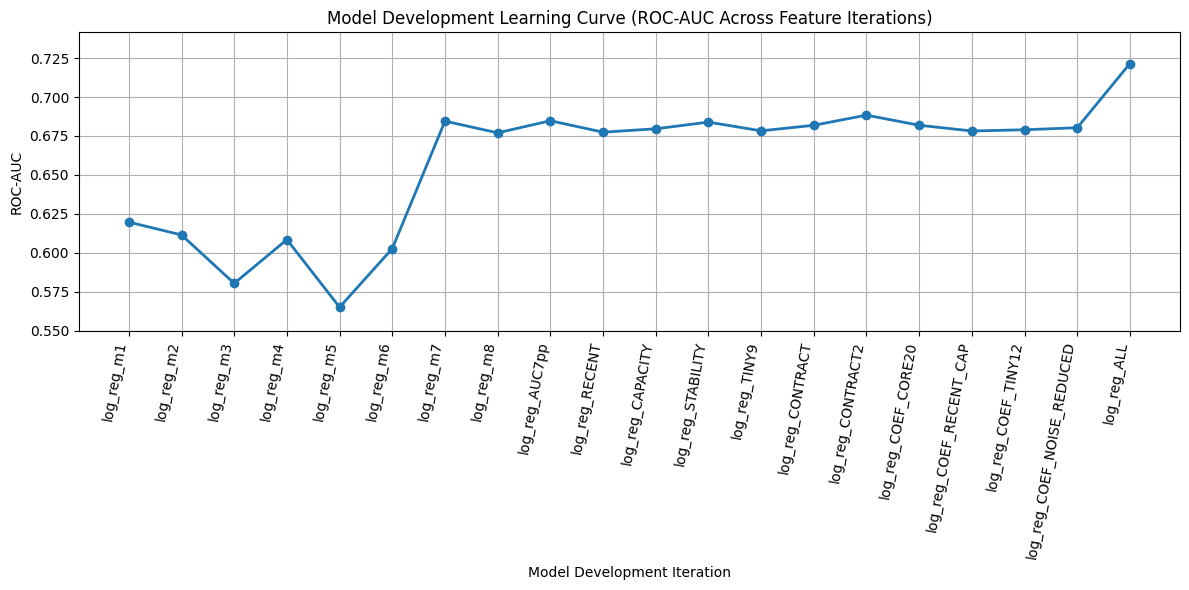

In [17]:
import matplotlib.pyplot as plt

# Ordered model keys in development order
ordered_model_keys = [
     "log_reg_m1","log_reg_m2","log_reg_m3","log_reg_m4",
    "log_reg_m5","log_reg_m6","log_reg_m7","log_reg_m8",
    "log_reg_AUC7pp","log_reg_RECENT","log_reg_CAPACITY",
    "log_reg_STABILITY","log_reg_TINY9","log_reg_CONTRACT",
    "log_reg_CONTRACT2","log_reg_COEF_CORE20",
    "log_reg_COEF_RECENT_CAP","log_reg_COEF_TINY12",
    "log_reg_COEF_NOISE_REDUCED", "log_reg_ALL"
]

# Extract ordered AUC values
auc_values = [model_results[k][2]["roc_auc"] for k in ordered_model_keys]

# Plot learning curve
plt.figure(figsize=(12,6))
plt.plot(range(1, len(auc_values)+1), auc_values, marker='o', linewidth=2)

plt.xticks(range(1, len(auc_values)+1), ordered_model_keys, rotation=80, ha='right')
plt.ylabel("ROC-AUC")
plt.xlabel("Model Development Iteration")
plt.title("Model Development Learning Curve (ROC-AUC Across Feature Iterations)")
plt.grid(True)
plt.ylim(0.55, max(auc_values) + 0.02)
plt.tight_layout()
plt.show()


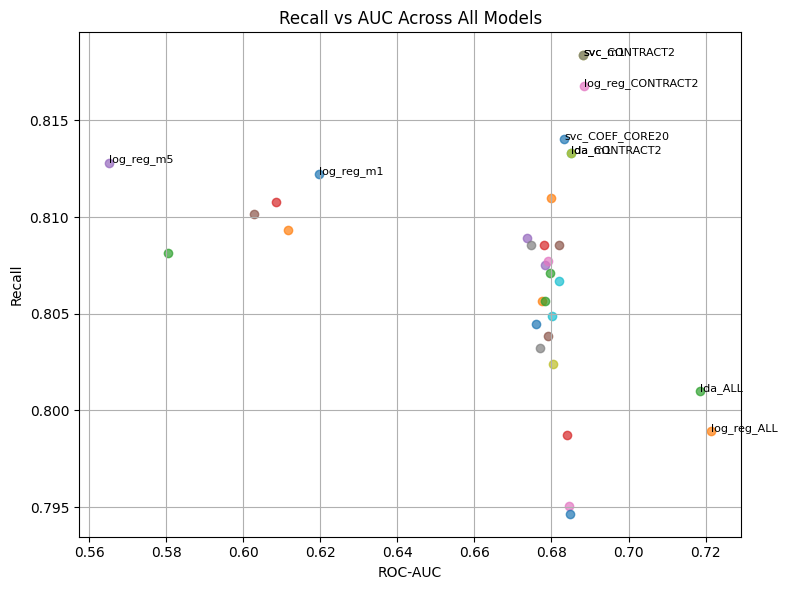

In [ ]:
points = []
for k, v in model_results.items():
    if isinstance(v, tuple):
        auc = v[2]["roc_auc"]
        rec = v[2]["recall"]
        points.append((k, auc, rec))

plt.figure(figsize=(8,6))

for name, auc, rec in points:
    plt.scatter(auc, rec, alpha=0.7)
    if auc > 0.70 or rec > 0.812:
        plt.text(auc, rec, name, fontsize=8)

plt.xlabel("ROC-AUC")
plt.ylabel("Recall")
plt.title("Recall vs AUC Across All Models")
plt.grid(True)
plt.tight_layout()
plt.show()


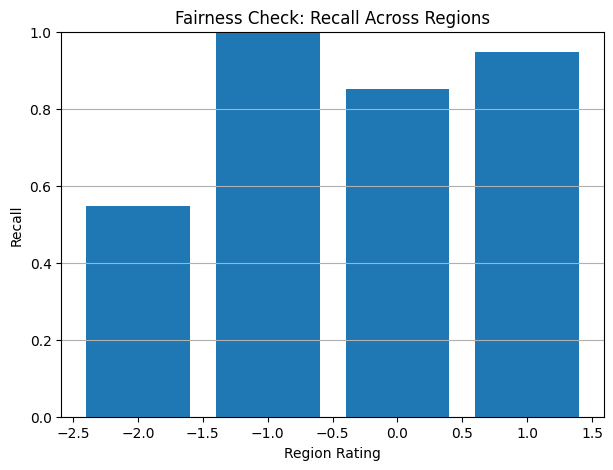

In [25]:
plt.figure(figsize=(7,5))
regions = list(recall_by_region_log_reg.keys())
scores  = list(recall_by_region_log_reg.values())

plt.bar(regions, scores)
plt.xlabel("Region Rating")
plt.ylabel("Recall")
plt.title("Fairness Check: Recall Across Regions")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()



Final high-corr feature list: ['TARGET', 'EXT_SOURCE_2', 'ext2_sq', 'prev_refused_rate', 'prev_share_mean_all', 'prev_rate_med_all', 'prev_rate_mean_all', 'prev_approved_rate', 'REGION_RATING', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher.education', 'prev_last5_approved_rate', 'DAYS_LAST_PHONE_CHANGE', 'phone_years', 'prev_last3_approved_rate', 'DAYS_ID_PUBLISH', 'id_years', 'NAME_EDUCATION_TYPE_Secondary...secondary.special', 'NAME_INCOME_TYPE_Pensioner', 'debt_ratio']


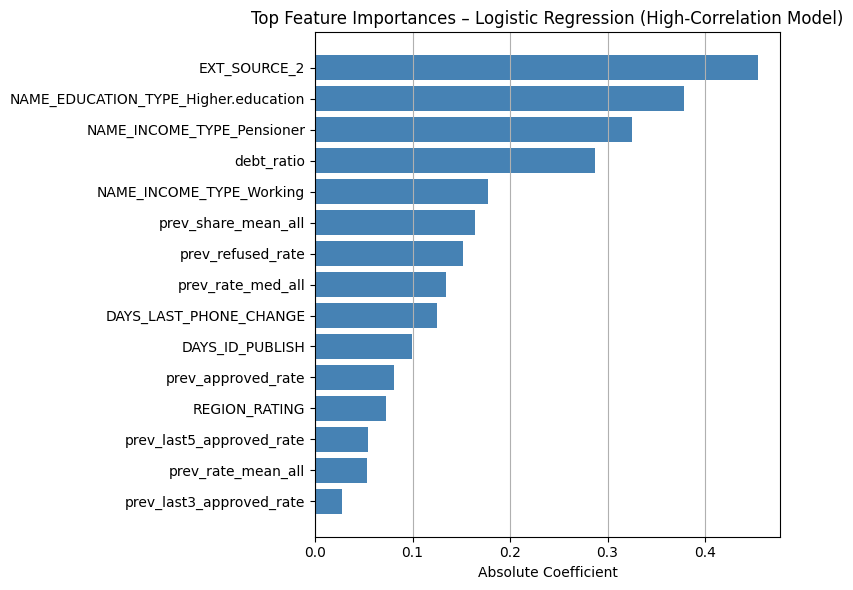

In [ ]:
high_corr_features = correlations[correlations > 0.045].index.tolist()

for bad in ["CODE_GENDER_M", "CODE_GENDER_F", "DAYS_BIRTH"]:
    if bad in high_corr_features:
        high_corr_features.remove(bad)

print("Final high-corr feature list:", high_corr_features)

train_df = train_data_stratified[high_corr_features].copy()
val_df   = val_data_stratified[high_corr_features].copy()

X_train = train_df.drop(columns=["TARGET"])
y_train = train_df["TARGET"]

log_reg.fit(X_train, y_train)

coefs = log_reg.coef_[0]
feature_names = X_train.columns.to_numpy()

order = np.argsort(np.abs(coefs))[::-1]
sorted_features = feature_names[order]
sorted_coefs = np.abs(coefs)[order]

TOP_K = 15  

plt.figure(figsize=(8,6))
plt.barh(sorted_features[:TOP_K], sorted_coefs[:TOP_K], color='steelblue')
plt.xlabel("Absolute Coefficient")
plt.title("Top Feature Importances – Logistic Regression (High-Correlation Model)")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()
